# Spurious Retransmissions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
import statistics
from common import *
from typing import List, Optional
from experiment import NetworkSetting
from data.http import HTTPExperiment
from data.media import MediaExperiment
from treatments.picoquic import treatment_map as http_treatment_map
from treatments.media import treatment_map as media_treatment_map

## Parse data

In [2]:
class DataPoint:
    def __init__(self, data: List[int]):
        self.n = len(data)
        self.mean = statistics.mean(data)
        self.stdev = 0 if len(data) <= 1 else statistics.stdev(data)
        self.median = statistics.median(data)
        self.p25 = np.percentile(data, 25)
        self.p75 = np.percentile(data, 75)

    def yerr_lower(self):
        return self.median - self.p25

    def yerr_upper(self):
        return self.p75 - self.median

In [3]:
# HTTP benchmark
http_labels = [
    'picoquic',
    'picoquic_split',
    'picoquic_sidekick_0ms',
    'picoquic_sidekick_30ms',
    'picoquic_sidekick_60ms',
    # 'picoquic_sidekick_60ms_hint',
    'picoquic_iblt_0ms',
    'picoquic_iblt_30ms',
    'picoquic_iblt_60ms',
    # 'picoquic_iblt_60ms_hint',
]
treatments = [http_treatment_map[label] for label in http_labels]
network_setting = NetworkSetting(bw1=20, bw2=20, delay1=1, delay2=100, loss1=4, loss2=0)
data_size = 125000 * 20 * 10 # 125000 * bottleneck_bw * time_s
exp = HTTPExperiment(num_trials=1, treatments=treatments, network_settings=[network_setting], data_sizes=[data_size])
http_raw_data = exp.to_raw_data(execute=False)

# Create plottable data

def plot_loss_vs_num_spurious(prefix, raw_data, sender: bool):
    key = 'Sender' if sender else 'Receiver'
    def num_spurious_func(output):
        if 'additional_data' not in output:
            return 0
        data_key = f'num_spurious_{key.lower()}'
        if data_key not in output['additional_data']:
            print(output['additional_data'])
        return output['additional_data'][data_key]
    
    title = f'{prefix} {data_size_str(DATA_SIZES()[0])} ({NETWORK_SETTINGS()[0].label()})'
    plottable_data = raw_data.to_plottlable_data(num_spurious_func)
    plot_loss_vs_metric_line(plottable_data, title=title, ylabel=f'Num Spurious Retransmissions ({key})')

http_data = {}
sender = False
for label in http_labels:
    outputs = http_raw_data.data[label][network_setting.label()][data_size]
    outputs = map(lambda output: output['additional_data']['num_spurious_receiver'] / output['time_s'], outputs)
    http_data[label] = DataPoint(list(outputs))

In [7]:
# Media benchmark
from treatments.media import labels as media_labels
duration = 30
treatments = [media_treatment_map[label] for label in media_labels]
network_setting = NetworkSetting(bw1=100, bw2=10, delay1=1, delay2=25, loss1=4, loss2=0)
exp = MediaExperiment(duration, treatments, network_setting)
media_raw_data = exp.to_raw_data(execute=True)

# Create plottable data
media_data = {}
for label in media_labels:
    output = media_raw_data.data[label]
    assert output.get('success')
    media_data[label] = DataPoint([output['client_num_spurious'] / duration])

34
sudo -E python3 emulation/main.py --loss1 4 --loss2 0 --label psum_delay0_hint --proxy sidekick --freq-ms 0 --threshold 8 --quack-hint --freq-pkts 2 --network-statistics media --client-quacker --ack-delay 0 --duration 30 31.592549800872803
sudo -E python3 emulation/main.py --loss1 4 --loss2 0 --label psum_delay0_nack --proxy sidekick --freq-ms 0 --threshold 8 --quack-nack --freq-pkts 0 --network-statistics media --client-quacker --ack-delay 0 --duration 30 31.583253622055054
sudo -E python3 emulation/main.py --loss1 4 --loss2 0 --label psum_delay5 --proxy sidekick --freq-ms 0 --threshold 8 --freq-pkts 2 --network-statistics media --client-quacker --ack-delay 5 --duration 30 31.5968017578125
sudo -E python3 emulation/main.py --loss1 4 --loss2 0 --label psum_delay5_hint --proxy sidekick --freq-ms 0 --threshold 8 --quack-hint --freq-pkts 2 --network-statistics media --client-quacker --ack-delay 5 --duration 30 31.589433908462524
sudo -E python3 emulation/main.py --loss1 4 --loss2 0 --l

## Plotting Functions

In [34]:
def plot_spurious_retransmissions(data, labels: List[str], title: str, ylim=0, pdf: Optional[str]=None):
    # Example data
    width = 1.0 / (len(labels) + 1)  # the width of the bars

    # Create plot
    fig, ax = plt.subplots(figsize=(4,3))
    for i, label in enumerate(labels):
        values = data[label].median
        ax.bar(width * (i - len(labels) / 2 + 0.5), values, width, label=label)
    
    # Add labels, title
    ax.set_ylabel('Num Spurious Retransmissions / Sec')
    ax.set_title(title)
    ax.set_ylim(ylim)

    # Add legend
    ncol = 1
    legend_height = 1.17
    legend_height += 0.06 * (math.ceil(len(labels) / ncol) - 1)
    ax.legend(loc='lower left', bbox_to_anchor=(1, 0), ncol=ncol)
    
    # Show plot
    if pdf:
        save_pdf(pdf)
    plt.show()

## Plot Data

In [30]:
# plot_spurious_retransmissions(http_data, http_labels, 'HTTP Benchmark', pdf='../figures/spurious_retx_http.pdf')

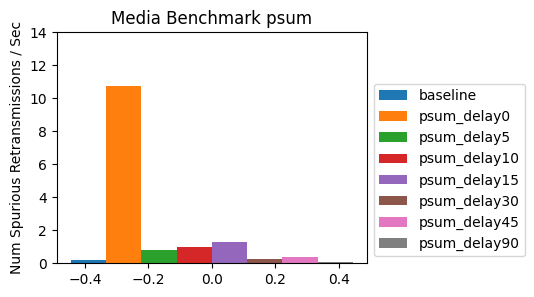

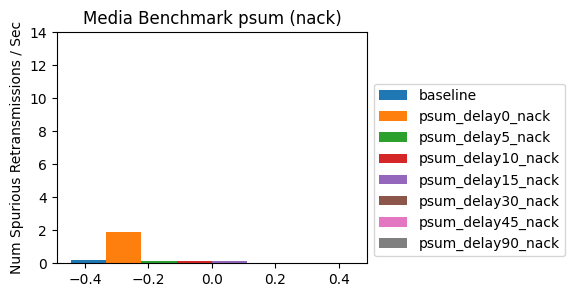

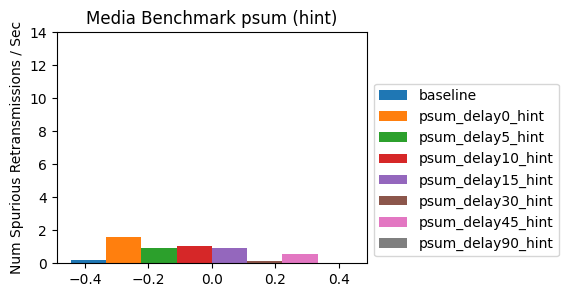

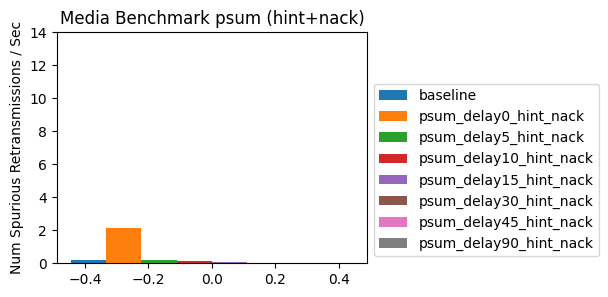

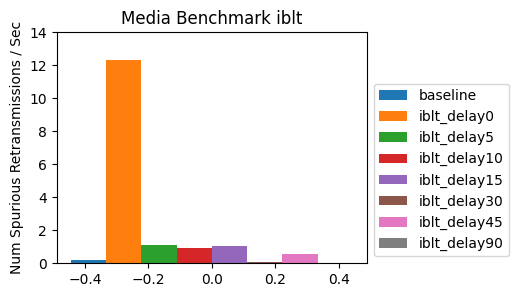

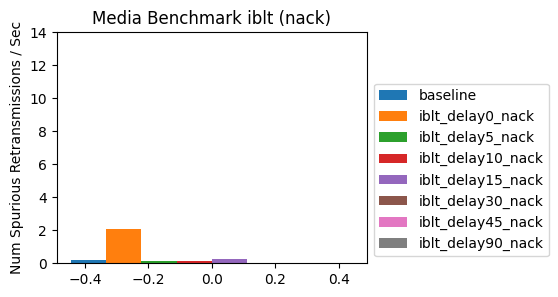

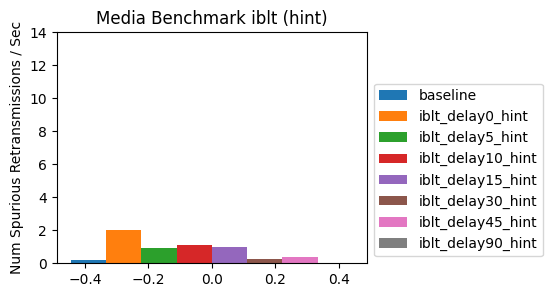

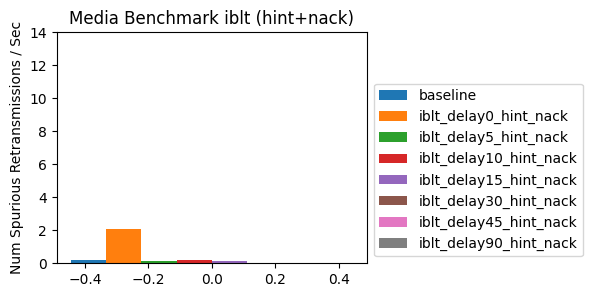

In [35]:
# 4. Sending with delay reduces spurious retx (keeps or improves perf).
delays = [0,5,10,15,30,45,90]
ylim = (0, 14)

def gen_labels(ty: str, hint: bool, nack: bool):
    labels = [f'{ty}_delay{delay}' for delay in delays]
    if hint:
        labels = [f'{label}_hint' for label in labels]
    if nack:
        labels = [f'{label}_nack' for label in labels]
    return ['baseline'] + labels

plot_spurious_retransmissions(media_data, gen_labels('psum', False, False), 'Media Benchmark psum', ylim=ylim)
plot_spurious_retransmissions(media_data, gen_labels('psum', False, True), 'Media Benchmark psum (nack)', ylim=ylim)
plot_spurious_retransmissions(media_data, gen_labels('psum', True, False), 'Media Benchmark psum (hint)', ylim=ylim)
plot_spurious_retransmissions(media_data, gen_labels('psum', True, True), 'Media Benchmark psum (hint+nack)', ylim=ylim)
plot_spurious_retransmissions(media_data, gen_labels('iblt', False, False), 'Media Benchmark iblt', ylim=ylim)
plot_spurious_retransmissions(media_data, gen_labels('iblt', False, True), 'Media Benchmark iblt (nack)', ylim=ylim)
plot_spurious_retransmissions(media_data, gen_labels('iblt', True, False), 'Media Benchmark iblt (hint)', ylim=ylim)
plot_spurious_retransmissions(media_data, gen_labels('iblt', True, True), 'Media Benchmark iblt (hint+nack)', ylim=ylim)

../figures/spurious_retx_media.pdf


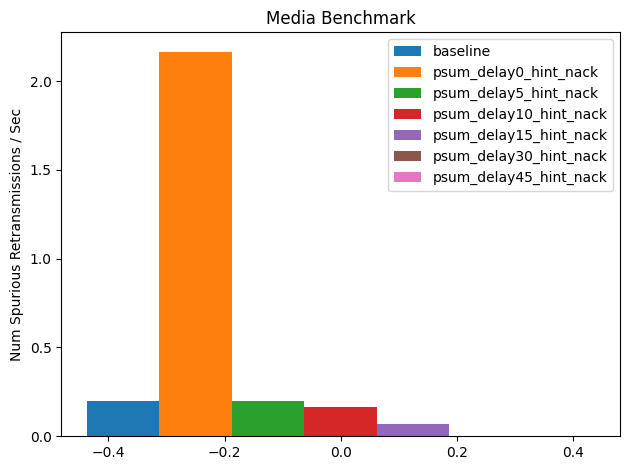

In [9]:
labels = [
    'baseline',
    'psum_delay0_hint_nack',
    'psum_delay5_hint_nack',
    'psum_delay10_hint_nack',
    'psum_delay15_hint_nack',
    'psum_delay30_hint_nack',
    'psum_delay45_hint_nack',
]
plot_spurious_retransmissions(media_data, labels, 'Media Benchmark', pdf='../figures/spurious_retx_media.pdf')